# Pair Correlation Function (PCF) for Spatial Relationships


In this tutorial, we introduces a novel implementation of PCF, that utilizes ligand–receptor (LR) database. 
A publically available implementation of PCF in spatial context either reveal relationships between two categorical values ([cross-PCF](https://docs.muspan.co.uk/latest/_collections/spatial_analysis_methods/Spatial%20stats%20-%201%20-%20pcf.html)), or between cetgorical and continues values ([wPCF](https://docs.muspan.co.uk/latest/_collections/spatial_analysis_methods/Spatial%20stats%20-%203%20-%20wPCF.html)). Here, we developed (name? **LRiPCF** (LR-informed PCF?) /  **kPCF** (knowledge-based PCF?)), a new method that utilizes previous knowledge, LR databases, and find relationship between two continues values (here represented as gene expression values).

The pair correlation function (gr) (or radial distribution) is defined as the ratio of the average density of point A at a distance r from a reference point B to the average total A points density. When **g(r) > 1**, point A and B are clustering, **g(r) < 1** indicate repulsion, while **g(r) = 1** means random distribution.

## How g(r) in LRwPCF is computed

##### (Equation here - to be added)

## 1. Load Packages

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scanpy as sc
import liana as li
import matplotlib.patches as mpatches
from matplotlib.patches import Annulus

## 2. Load and Prep Data

To demonstrate the LRwPCF in practice, we will apply it to a spatial transcriptomics dataset from [A molecularly defined and spatially resolved cell atlas of the whole mouse brain(Nature, 2023)](https://www.nature.com/articles/s41586-023-06808-9); [WB_MERFISH_animal2_coronal](https://cellxgene.cziscience.com/collections/0cca8620-8dee-45d0-aef5-23f032a5cf09).

The dataset was generated using **MERFISH** technique, which enables highly multiplexed single-molecule RNA imaging with subcellular spatial resolution. This dataset profiles the expression of more than **1,000** genes across roughly **10 million cells** in the adult **mouse brain**.

In [2]:
file_path  = "data/MERFISH_mouse_brain/WB_MERFISH_animal2_coronal.h5ad"
backup_url = "https://datasets.cellxgene.cziscience.com/93c3bb97-ea05-4ee0-a760-a1508cd04612.h5ad"

adata = sc.read(file_path) if os.path.exists(file_path) else sc.read(file_path, backup_url=backup_url)

# Subset to one section and set gene names
adata = adata[adata.obs["brain_section_label"] == "C57BL6J-2.039"]
adata.var_names = adata.var["gene_name"]

# Basic QC
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)

# Normalise (keep raw counts in a layer)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

print(adata)

AnnData object with n_obs × n_vars = 51539 × 1120
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
    uns: 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title', 'log1p'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap'
    layers: 'counts'


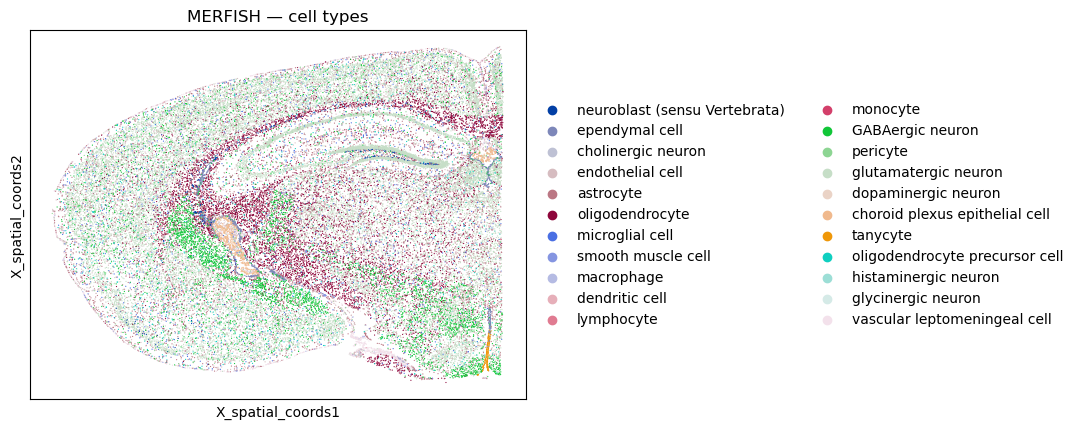

In [3]:
sc.pl.embedding(
    adata, basis="X_spatial_coords",
    color="cell_type", s=3, title="MERFISH — cell types"
)

## 3. Ligand–Receptor Database

In [4]:
resource = li.rs.select_resource('mouseconsensus')
print(f"{len(resource)} LR pairs in resource")
resource.head(5)

3989 LR pairs in resource


,ligand,receptor
31371,Dll1,Notch1
31372,Dll1,Notch2
31373,Dll1,Notch4
31374,Dll1,Notch3
31375,Nrg2,Erbb2_Erbb3


## 4. Cross-PCF: Baseline Spatial Structure

The cross-PCF answers a **purely spatial** question:

> Are cells of type B more (or less) frequent around cells of type A at distance r than expected under complete spatial randomness?

It treats all cells **equally**. Gene expression is not considered. We use it to characterise the raw spatial architecture of the tissue before asking about LR interactions.

### Choose the right parameters
**radius_step** = this parameter decide how large is the step between bins. <br>
**annulus_width** = width of annulus ring. <br>
It is best to set annulus_width = radius_step so we avoid points double-counting. <br>
**max_radius** = the inner radius  of the last and largets bin.

In [5]:
def plot_annulus_on_tissue(
    adata,
    spatial_key="X_spatial_coords",
    groupby="cell_type",
    annulus_width=20,
    radius_step=20,
    n_rings=14,
    seed=42,
):
    coords  = adata.obsm[spatial_key]
    ct_vals = adata.obs[groupby].astype("category")
    cats    = ct_vals.cat.categories.tolist()

    # Reuse scanpy's colour palette if available, else fall back to tab20
    palette_key = f"{groupby}_colors"
    if palette_key in adata.uns:
        ct_color_map = dict(zip(cats, adata.uns[palette_key]))
    else:
        cmap = plt.cm.get_cmap("tab20", len(cats))
        ct_color_map = {ct: cmap(i) for i, ct in enumerate(cats)}

    # 10 consecutive rings: ring k has inner = k*radius_step, outer = k*radius_step + annulus_width
    sel_inner = np.arange(1, n_rings + 1, dtype=float) * radius_step
    sel_outer = sel_inner + annulus_width

    # Random center cell
    rng    = np.random.default_rng(seed)
    center = coords[rng.integers(len(coords))]
    dists  = np.linalg.norm(coords - center, axis=1)

    counts = [int(np.sum((dists >= r_in) & (dists < r_out)))
              for r_in, r_out in zip(sel_inner, sel_outer)]

    ring_colors = plt.cm.plasma(np.linspace(0.05, 0.90, n_rings))
    view_r      = sel_outer[-1] * 1.2
    near_mask   = dists <= view_r

    # ── figure: wide left panel (full tissue) + square right panel (zoom) ──
    fig = plt.figure(figsize=(18, 7))
    gs  = fig.add_gridspec(1, 2, width_ratios=[1.35, 1.0], wspace=0.06)
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1])

    # ── LEFT: full tissue coloured by cell type ─────────────────────────────
    for ct in cats:
        mask = ct_vals.values == ct
        ax0.scatter(coords[mask, 0], coords[mask, 1],
                    s=2, c=ct_color_map[ct], alpha=0.6,
                    linewidths=0, rasterized=True, label=ct)

    # White dashed circle = outermost ring, so viewer can locate the zoom region
    ax0.add_patch(plt.Circle(center, sel_outer[-1],
                             fill=False, edgecolor="white", lw=1.5, ls="--", zorder=5))
    ax0.scatter(*center, s=80, c="white", marker="*",
                zorder=10, edgecolors="black", linewidths=0.6)

    ax0.set_aspect("equal")
    ax0.axis("off")
    ax0.set_title("★ = center cell, dashed = ring extent",
                  fontsize=10, pad=8)
    ax0.legend(
        loc="lower left", fontsize=6.5, frameon=True, framealpha=0.85,
        markerscale=2, ncol=2, title=groupby, title_fontsize=7,
        bbox_to_anchor=(0, 0),
    )

    # ── RIGHT: zoomed view with 14 rings ────────────────────────────────────
    for ct in cats:
        mask = (ct_vals.values == ct) & near_mask
        if mask.any():
            ax1.scatter(coords[mask, 0], coords[mask, 1],
                        s=12, c=ct_color_map[ct], alpha=0.85,
                        linewidths=0, zorder=1)

    # Draw annuli outermost → innermost so inner rings sit on top
    for r_in, r_out, color in zip(sel_inner[::-1], sel_outer[::-1], ring_colors[::-1]):
        ax1.add_patch(Annulus(center, r=r_out, width=r_out - r_in,
                              color=color, alpha=0.22, zorder=2))
        ax1.add_patch(plt.Circle(center, r_out,
                                 fill=False, edgecolor=color, lw=1.8, zorder=4))
        ax1.add_patch(plt.Circle(center, r_in,
                                 fill=False, edgecolor=color, lw=0.8, ls="--", zorder=4))

    # Cell-count badge at 45° inside each ring
    for r_in, r_out, color, count in zip(sel_inner, sel_outer, ring_colors, counts):
        mid_r = (r_in + r_out) / 2
        lx = center[0] + mid_r * np.cos(np.pi / 4)
        ly = center[1] + mid_r * np.sin(np.pi / 4)
        ax1.text(lx, ly, f"n={count}", ha="center", va="center",
                 fontsize=7, color="white", fontweight="bold", zorder=6,
                 bbox=dict(boxstyle="round,pad=0.22", facecolor=color,
                           edgecolor="none", alpha=0.92))

    ax1.scatter(*center, s=180, c="black", marker="*", zorder=10)

    ax1.set_xlim(center[0] - view_r, center[0] + view_r)
    ax1.set_ylim(center[1] - view_r, center[1] + view_r)
    ax1.set_aspect("equal")
    ax1.set_xlabel("x (µm)", fontsize=9)
    ax1.set_ylabel("y (µm)", fontsize=9)

    # Title: parameters + per-ring counts
    count_lines = "\n".join(
        "     ".join(
            f"Ring {i+1} [{r_in:.0f}–{r_out:.0f}µm]: {n} cells"
            for i, (r_in, r_out, n) in enumerate(zip(
                sel_inner[row*5:(row+1)*5],
                sel_outer[row*5:(row+1)*5],
                counts[row*5:(row+1)*5],
            ))
        )
        for row in range((n_rings + 4) // 5)
    )
    ax1.set_title(
        f"14 consecutive annuli  |  annulus_width = {annulus_width} µm  "
        f"|  radius_step = {radius_step} µm\n\n"
        f"{count_lines}",
        fontsize=8.5, pad=12, linespacing=1.65,
    )

    # Ring colour legend
    ring_patches = [
        mpatches.Patch(facecolor=c, alpha=0.7,
                       label=f"Ring {i+1}: [{r_in:.0f}–{r_out:.0f} µm]")
        for i, (r_in, r_out, c) in enumerate(zip(sel_inner, sel_outer, ring_colors))
    ]
    ax1.legend(handles=ring_patches, loc="lower right", fontsize=6.5,
               frameon=True, framealpha=0.9, title="Annuli", title_fontsize=7, ncol=2)

    plt.show()

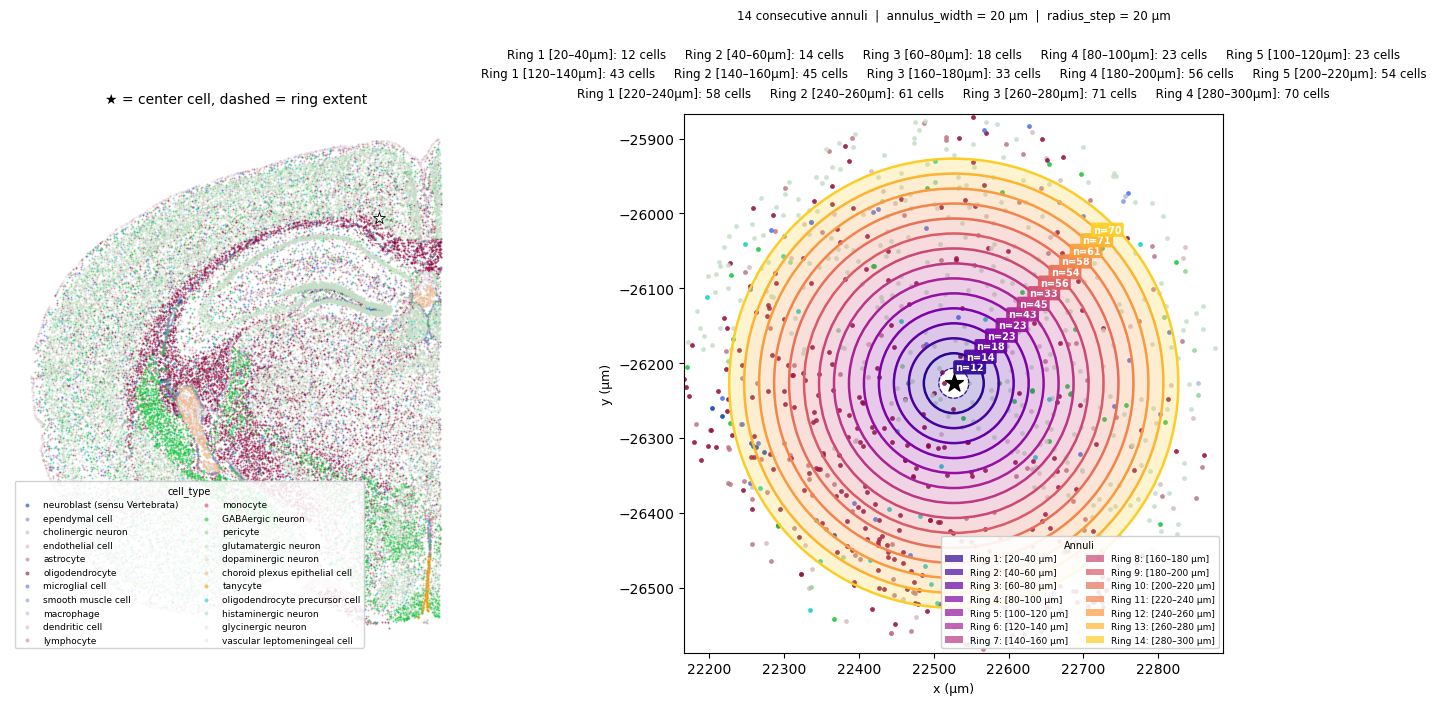

In [6]:
plot_annulus_on_tissue(
    adata,
    spatial_key="X_spatial_coords",
    groupby="cell_type",
    annulus_width=20,
    radius_step=20,
    n_rings=14,
    seed=42,
)

### Run cross-PCF 

In [7]:
li.mt.cross_pcf(
    adata,
    groupby="cell_type",
    spatial_key="X_spatial_coords",
    max_radius=300,
    radius_step=20,
    annulus_width=20,
    min_cells=100,
    key_added="cross_pcf",
    verbose=True,
)

Dropping 7 cell type(s) with fewer than 100 cells: ['cholinergic neuron', 'dendritic cell', 'dopaminergic neuron', 'glycinergic neuron', 'histaminergic neuron', 'lymphocyte', 'monocyte']
Computing cross-PCF for 15 cell types (210 directed pairs).
cross-PCF:   0%|                                        | 0/210 [00:00<?, ?it/s]

cross-PCF: 100%|██████████████████████████████| 210/210 [00:55<00:00,  3.80it/s]


We can get g(r) value for cell type interactions as follow:

In [8]:
cpcf = adata.uns["cross_pcf"]
snd, rcv = "ependymal cell", "choroid plexus epithelial cell"
print(f"\ng(r) for {snd} → {rcv}:")
print(cpcf["results"][(snd, rcv)])


g(r) for ependymal cell → choroid plexus epithelial cell:
[ 8.2830393   8.41824494  8.38242471  8.9625939   9.88998319 10.48391521
 10.35771226  9.79957583 17.75196402 11.21621617 25.28640618  9.91858245
  8.79894254  6.83168531  5.87544493]


### 4a. Aggregation: cells cluster together

**Ependymal cells** and **choroid plexus epithelial cells** both line the ventricular system and are expected to be spatially co-localised. We expect **g(r) >> 1** at short distances.

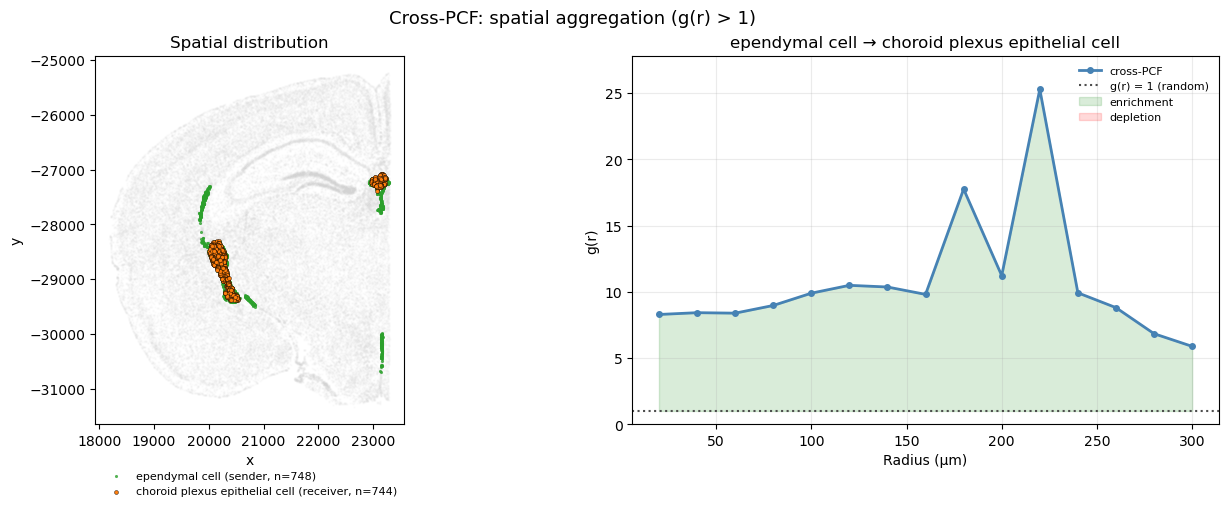

In [9]:
def plot_crosspcf_pair(adata, cpcf, sender, receiver, title=""):
    """Spatial map + cross-PCF curve for one directed cell-type pair."""
    coords = adata.obsm["X_spatial_coords"]
    ct = adata.obs["cell_type"].astype(str).values

    snd_mask   = ct == sender
    rcv_mask   = ct == receiver
    other_mask = ~(snd_mask | rcv_mask)

    g = np.asarray(cpcf["results"][(sender, receiver)], dtype=float)
    r = np.asarray(cpcf["radii"], dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained",
                             gridspec_kw={"width_ratios": [1.1, 1.0]})

    # Spatial distribution
    ax0 = axes[0]
    ax0.scatter(coords[other_mask, 0], coords[other_mask, 1],
                s=2, c="lightgray", alpha=0.1, linewidths=0, rasterized=True)
    ax0.scatter(coords[snd_mask, 0], coords[snd_mask, 1],
                s=5, c="tab:green", alpha=0.8, linewidths=0, rasterized=True,
                label=f"{sender} (sender, n={snd_mask.sum():,})")
    ax0.scatter(coords[rcv_mask, 0], coords[rcv_mask, 1],
                s=8, c="tab:orange", alpha=1.0, edgecolors="black",
                linewidths=0.3, rasterized=True,
                label=f"{receiver} (receiver, n={rcv_mask.sum():,})")
    ax0.set_aspect("equal"); ax0.set_xlabel("x"); ax0.set_ylabel("y")
    ax0.set_title("Spatial distribution")
    ax0.legend(frameon=False, fontsize=8, loc="upper left",
               bbox_to_anchor=(0, -0.1), ncol=1)

    # Cross-PCF curve
    ax1 = axes[1]
    ax1.plot(r, g, lw=2, marker="o", ms=4, color="steelblue", label="cross-PCF")
    ax1.axhline(1, linestyle=":", color="0.3", lw=1.5, label="g(r) = 1 (random)")
    ax1.fill_between(r, 1, g, where=g > 1, alpha=0.15, color="green", label="enrichment")
    ax1.fill_between(r, g, 1, where=g < 1, alpha=0.15, color="red",   label="depletion")
    ax1.set_xlabel("Radius (µm)"); ax1.set_ylabel("g(r)")
    ax1.set_ylim(0, max(1.5, np.nanmax(g) * 1.1))
    ax1.set_title(f"{sender} → {receiver}")
    ax1.legend(frameon=False, fontsize=8); ax1.grid(alpha=0.25)

    fig.suptitle(title or f"Cross-PCF: {sender} → {receiver}", fontsize=13)
    plt.show()


plot_crosspcf_pair(
    adata, cpcf,
    sender="ependymal cell",
    receiver="choroid plexus epithelial cell",
    title="Cross-PCF: spatial aggregation (g(r) > 1)"
)

### 4b. Exclusion: cells avoid each other

**Choroid plexus epithelial cells** are confined to the ventricular choroid plexus, while **glutamatergic neurons** are broadly distributed in the parenchyma. They occupy non-overlapping spatial compartments, so we expect **g(r) << 1**.

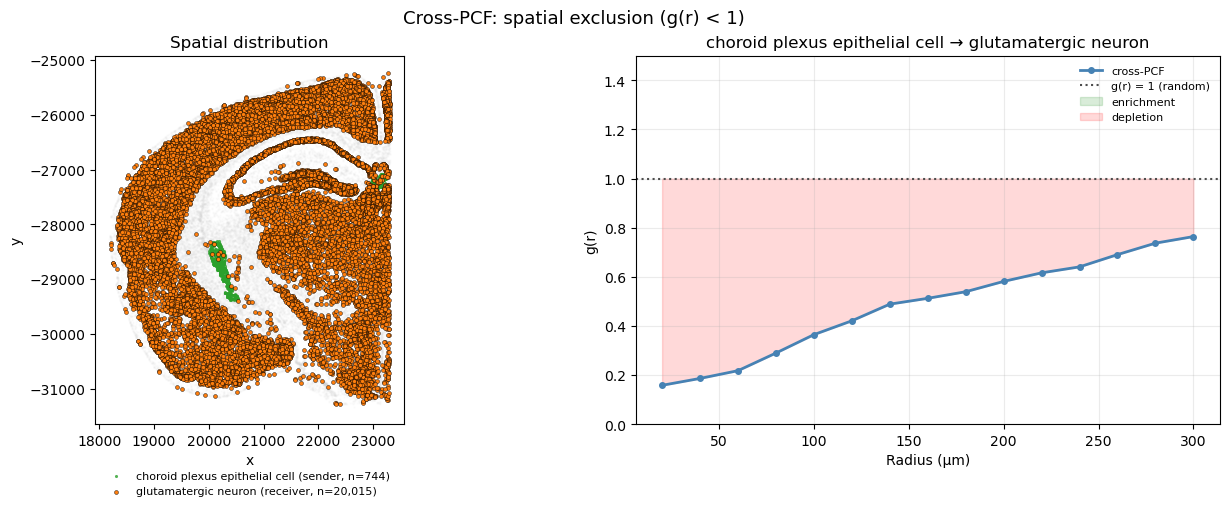

In [10]:
plot_crosspcf_pair(
    adata, cpcf,
    sender="choroid plexus epithelial cell",
    receiver="glutamatergic neuron",
    title="Cross-PCF: spatial exclusion (g(r) < 1)"
)

## 5. Global Ligand–Receptor Screen using wPCF

The **agnostic** mode of `lr_wpcf` ignores cell-type labels and asks:

> Across all cells in the tissue, is the **ligand signal** from potential senders spatially enriched around **receptor-expressing** receiver cells at distance r?


Here, because all cells are pooled, the signal can be inflated by tissue compartment structure, so a high agnostic score does not guarantee that the interaction is biologically directed between specific cell types.

In [12]:
li.mt.lr_wpcf(
    adata,
    resource=resource,
    spatial_key="X_spatial_coords",
    max_radius=300,
    radius_step=20,
    annulus_width=20,
    use_raw=False,          
    key_added="lr_wpcf_ag",
    verbose=True,
)

Running cell-type-agnostic LR-wPCF.


Using provided `resource`.


In [13]:
ag = adata.uns["lr_wpcf_ag"]
ag_pairs = ag["pair_names"]
ag_wpcf = ag["wpcf"]
ag_radii = ag["radii"]

### 5a. Rank LR Pairs by Signal

Useful summary statistics here:
- **`mean_wpcf`**: average g(r) across all radii (overall spatial co-enrichment)
- **`max_wpcf`**: peak g(r) (strength of the strongest spatial enrichment at any distance)
- **`peak_radius`**: distance at which g(r) is highest (characteristic interaction range)

In [14]:
pair_scores = pd.DataFrame({
    "pair"          : ag_pairs,
    "mean_wpcf"     : np.abs(ag_wpcf).mean(axis=0),
    "max_abs_wpcf"  : np.abs(ag_wpcf).max(axis=0),
    "peak_radius"   : ag_radii[np.abs(ag_wpcf).argmax(axis=0)],
}).sort_values(
    ["max_abs_wpcf", "peak_radius"],
    ascending=[False, True]
).reset_index(drop=True)

print("Top 5 LR pairs by absolute peak wPCF:")
pair_scores.head(5)

Top 5 LR pairs by absolute peak wPCF:


,pair,mean_wpcf,max_abs_wpcf,peak_radius
0,Tac2^Tacr1,5.984931,7.406234,20.0
1,Lamb3^Cd44,1.904346,7.401892,260.0
2,Gal^Galr1,4.766402,5.562160,20.0
3,Vcan^Cd44,1.587030,4.280123,260.0
4,Ntf3^Ntrk3,2.215452,4.107326,20.0


### 5b. Top pairs across distance

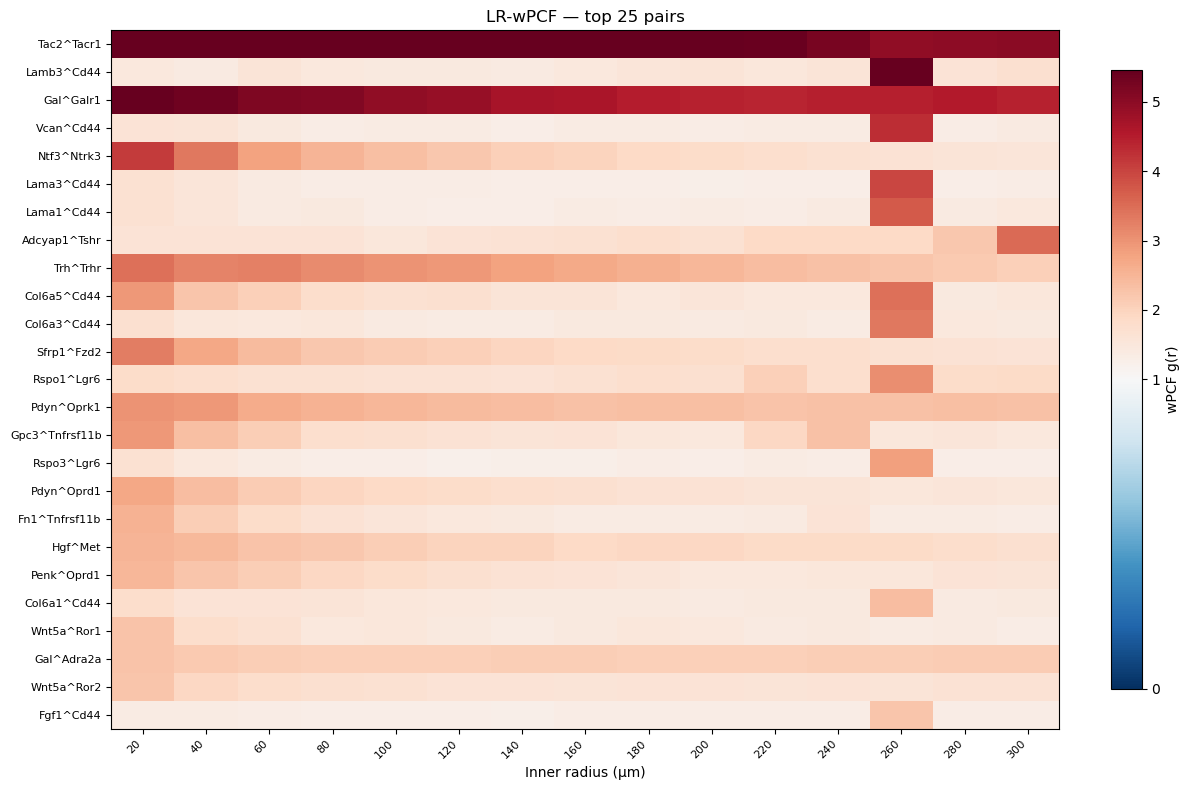

In [15]:
TOP_N = 25

top_pairs = pair_scores.head(TOP_N)["pair"].tolist()
top_idx   = [ag_pairs.index(p) for p in top_pairs]
top_mat   = ag_wpcf[:, top_idx].T  # (TOP_N, n_bins)

vmax = np.percentile(top_mat, 97)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(
    top_mat, aspect="auto", origin="upper", cmap="RdBu_r",
    norm=mcolors.TwoSlopeNorm(vmin=0, vcenter=1, vmax=vmax)
)
plt.colorbar(im, ax=ax, label="wPCF g(r)", fraction=0.03)
ax.set_xticks(range(len(ag_radii)))
ax.set_xticklabels(ag_radii.astype(int), rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(top_pairs, fontsize=8)
ax.set_xlabel("Inner radius (µm)")
ax.set_title(f"LR-wPCF — top {TOP_N} pairs")
plt.tight_layout()
plt.show()

### 5c. Distance profiles for top-ranked pairs

The shape of g(r) tells the **characteristic range** of the interaction:
- Peak at short radius → likely contact-range or paracrine signalling
- Broad plateau → long-range / endocrine-like enrichment
- Rising curve that doesn't drop → pairs driven by tissue compartment co-localisation

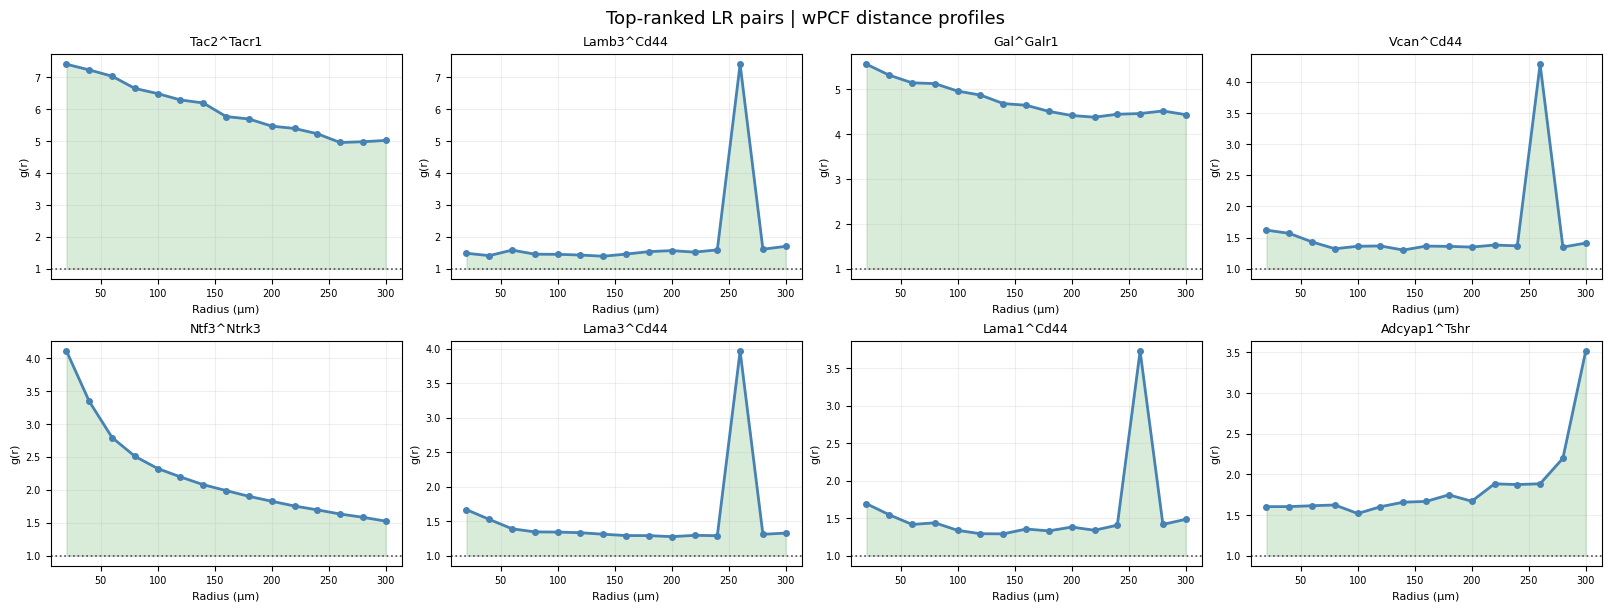

In [16]:
PLOT_N = 8

top8 = pair_scores.head(PLOT_N)["pair"].tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 6), layout="constrained")
for ax, pair in zip(axes.flat, top8):
    idx = ag_pairs.index(pair)
    g   = ag_wpcf[:, idx]
    ax.plot(ag_radii, g, lw=2, marker="o", ms=4, color="steelblue")
    ax.axhline(1, linestyle=":", color="0.3", lw=1.2)
    ax.fill_between(ag_radii, 1, g, where=g > 1, alpha=0.15, color="green")
    ax.fill_between(ag_radii, g, 1, where=g < 1, alpha=0.15, color="red")
    ax.set_title(pair, fontsize=9)
    ax.set_xlabel("Radius (µm)", fontsize=8)
    ax.set_ylabel("g(r)", fontsize=8)
    ax.grid(alpha=0.2); ax.tick_params(labelsize=7)

fig.suptitle("Top-ranked LR pairs | wPCF distance profiles", fontsize=13)
plt.show()

## 6. LRwPCF Cell-Type Informed for Directed Interactions

The **cell-type-informed** mode splits cells into sender and receiver populations by cell type annotation and computes g(r) for every directed **(sender → receiver)** pair weighted by the LR expression.

This answers a more specific question:

> For the specific interaction **sender cell type X expressing ligand L** → **receiver cell type Y expressing receptor R**, is the LR-weighted spatial co-enrichment at distance r higher than expected?

**Key advantage over cross-PCF**: the expression weighting means g(r) > 1 can only come from cells that express the relevant ligand/receptor, it cannot be inflated by a cell type that merely happens to be spatially close.

In [17]:
li.mt.lr_wpcf(
    adata,
    resource=resource,
    groupby="cell_type",
    spatial_key="X_spatial_coords",
    max_radius=300,
    radius_step=20,
    annulus_width=20,
    min_cells=100,
    use_raw=False,
    key_added="lr_wpcf_ct",
    verbose=True,
)

Dropping 7 cell type(s) with fewer than 100 cells: ['cholinergic neuron', 'dendritic cell', 'dopaminergic neuron', 'glycinergic neuron', 'histaminergic neuron', 'lymphocyte', 'monocyte']
Running LR-wPCF for 15 cell types (210 directed pairs).


Using provided `resource`.


LR-wPCF: 100%|████████████████████████████████| 210/210 [00:58<00:00,  3.60it/s]


In [18]:
ct = adata.uns["lr_wpcf_ct"]

ct_wpcf      = ct["results"]    # dict: (sender, receiver) → (n_bins, n_pairs)
ct_pairs     = ct["pair_names"]
ct_radii     = ct["radii"]
ct_types     = ct["cell_types"]


# Access one specific curve: sender, receiver, LR pair
snd, rcv = "GABAergic neuron", "glutamatergic neuron"
pair = next(p for p in ct_pairs if "Ntf3" in p and "Ntrk3" in p)
print(f"\nPair name: {pair}")

g_example = ct_wpcf[(snd, rcv)][:, ct_pairs.index(pair)]
print(f"g(r) for {snd} → {rcv}, {pair}:")
print(g_example)


Pair name: Ntf3^Ntrk3
g(r) for GABAergic neuron → glutamatergic neuron, Ntf3^Ntrk3:
[1.314797  1.3062994 1.2638075 1.1840137 1.1649932 1.1515472 1.0943186
 1.049495  1.0996864 1.0576961 1.0990777 1.0741421 1.049673  1.059719
 1.0944602]


### 6a. Cross-PCF vs LR-wPCF: Does expression add information?

Cross-PCF captures spatial structure. If wPCF tracks cross-PCF closely, the LR pair's signal is mostly explained by where the two cell types happen to be. If wPCF **exceeds** cross-PCF, the expression weighting is amplifying a real biological signal: cells that express the ligand/receptor are not distributed randomly within their cell type but they cluster near each other.

We compare cross-PCF, agnostic wPCF, and CT-specific wPCF for **Ntf3→Ntrk3** (neurotrophin signalling) on the GABAergic → glutamatergic axis.

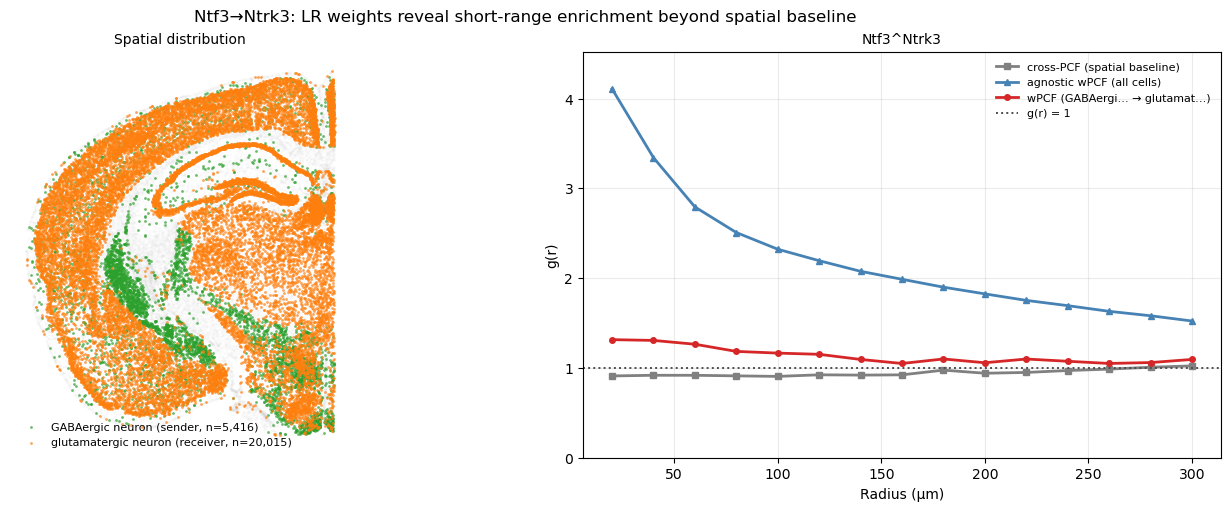

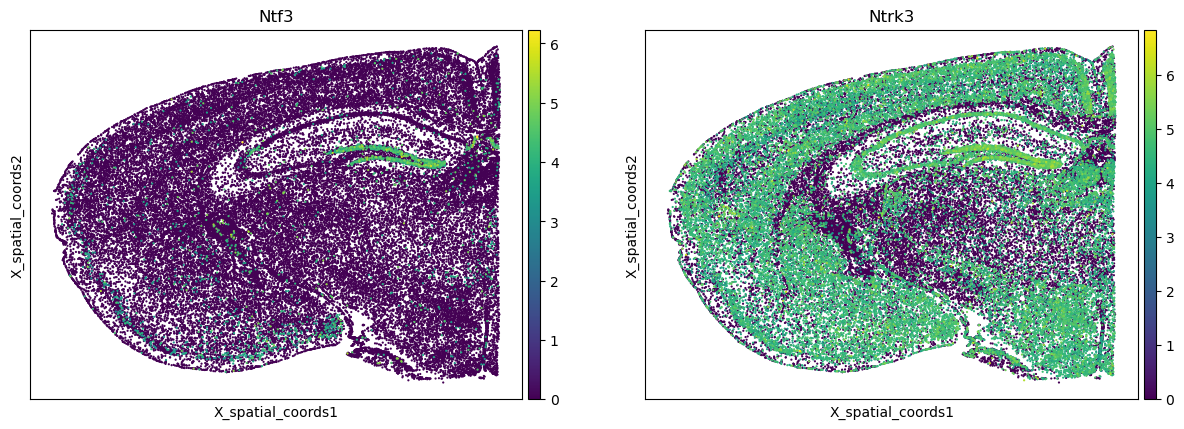

In [19]:
def three_way_plot(adata, cpcf, ag, ct, snd, rcv, lr_pair, title=""):
    """Plot cross-PCF, agnostic wPCF, and CT-specific wPCF side by side."""
    coords = adata.obsm["X_spatial_coords"]
    ct_labels = adata.obs["cell_type"].astype(str).values

    snd_mask   = ct_labels == snd
    rcv_mask   = ct_labels == rcv
    other_mask = ~(snd_mask | rcv_mask)

    p_ag = ag["pair_names"].index(lr_pair)
    p_ct = ct["pair_names"].index(lr_pair)

    r_c  = np.asarray(cpcf["radii"], dtype=float)
    g_c  = np.asarray(cpcf["results"].get((snd, rcv), np.full_like(r_c, np.nan)), dtype=float)
    r_ag = np.asarray(ag["radii"], dtype=float)
    g_ag = np.asarray(ag["wpcf"][:, p_ag], dtype=float)
    r_ct = np.asarray(ct["radii"], dtype=float)
    g_ct = np.asarray(ct["results"][(snd, rcv)][:, p_ct], dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), layout="constrained",
                             gridspec_kw={"width_ratios": [1.1, 1.0]})

    # Spatial map
    ax0 = axes[0]
    ax0.scatter(coords[other_mask, 0], coords[other_mask, 1],
                s=2, c="lightgray", alpha=0.08, linewidths=0, rasterized=True)
    ax0.scatter(coords[snd_mask, 0], coords[snd_mask, 1],
                s=4, c="tab:green", alpha=0.7, linewidths=0, rasterized=True,
                label=f"{snd} (sender, n={snd_mask.sum():,})")
    ax0.scatter(coords[rcv_mask, 0], coords[rcv_mask, 1],
                s=4, c="tab:orange", alpha=0.7, linewidths=0, rasterized=True,
                label=f"{rcv} (receiver, n={rcv_mask.sum():,})")
    ax0.set_aspect("equal"); ax0.axis("off")
    ax0.set_title("Spatial distribution", fontsize=10)
    ax0.legend(frameon=False, fontsize=8, loc="lower left")

    # Three curves
    ax1 = axes[1]
    ax1.plot(r_c,  g_c,  lw=2, marker="s", ms=4, color="0.5",       label="cross-PCF (spatial baseline)")
    ax1.plot(r_ag, g_ag, lw=2, marker="^", ms=4, color="steelblue", label="agnostic wPCF (all cells)")
    ax1.plot(r_ct, g_ct, lw=2, marker="o", ms=4, color="tab:red",   label=f"wPCF ({snd[:8]}… → {rcv[:8]}…)")
    ax1.axhline(1, linestyle=":", color="0.3", lw=1.4, label="g(r) = 1")
    ax1.set_xlabel("Radius (µm)"); ax1.set_ylabel("g(r)")
    ax1.set_title(f"{lr_pair}", fontsize=10)
    ymax = np.nanmax([np.nanmax(g_c), np.nanmax(g_ag), np.nanmax(g_ct)])
    ax1.set_ylim(0, max(1.5, ymax * 1.1))
    ax1.legend(frameon=False, fontsize=8); ax1.grid(alpha=0.25)

    fig.suptitle(title or f"{snd} → {rcv}: {lr_pair}", fontsize=12)
    plt.show()


# Neurotrophin 3 → TrkC receptor: known short-range neurotrophic interaction
pair_ntf3 = next(p for p in ct_pairs if "Ntf3" in p and "Ntrk3" in p)

three_way_plot(
    adata, cpcf, ag, ct,
    snd="GABAergic neuron",
    rcv="glutamatergic neuron",
    lr_pair=pair_ntf3,
    title="Ntf3→Ntrk3: LR weights reveal short-range enrichment beyond spatial baseline"
)

sc.pl.embedding(
    adata,
    basis="X_spatial_coords",
    color=["Ntf3", "Ntrk3"],
    s=10,
    use_raw=False,
    ncols=2,
)


We notice that CT-specific wPCF (red) peaks above the cross-PCF (grey) at short distances, the Ntf3/Ntrk3 expression pattern reinforces the spatial proximity signal, GABAergic cells that express Ntf3 tend to be found near glutamatergic cells that express Ntrk3, beyond what the overall cell-type co-localisation would predict.

### 6b. LR weights can amplify exclusion

**Efna5→Epha4/5**: Ephrin–Eph signalling is a canonical **repulsive** guidance cue between neuronal populations. We expect the LR-weighted g(r) to fall **below** cross-PCF, because the cells that express these genes show even stronger spatial avoidance than the overall cell-type distribution would suggest.

Efna5 pairs available: ['Efna5^Epha1', 'Efna5^Epha3', 'Efna5^Epha8', 'Efna5^Ephb1', 'Efna5^Epha4', 'Efna5^Epha7', 'Efna5^Epha10', 'Efna5^Epha6']


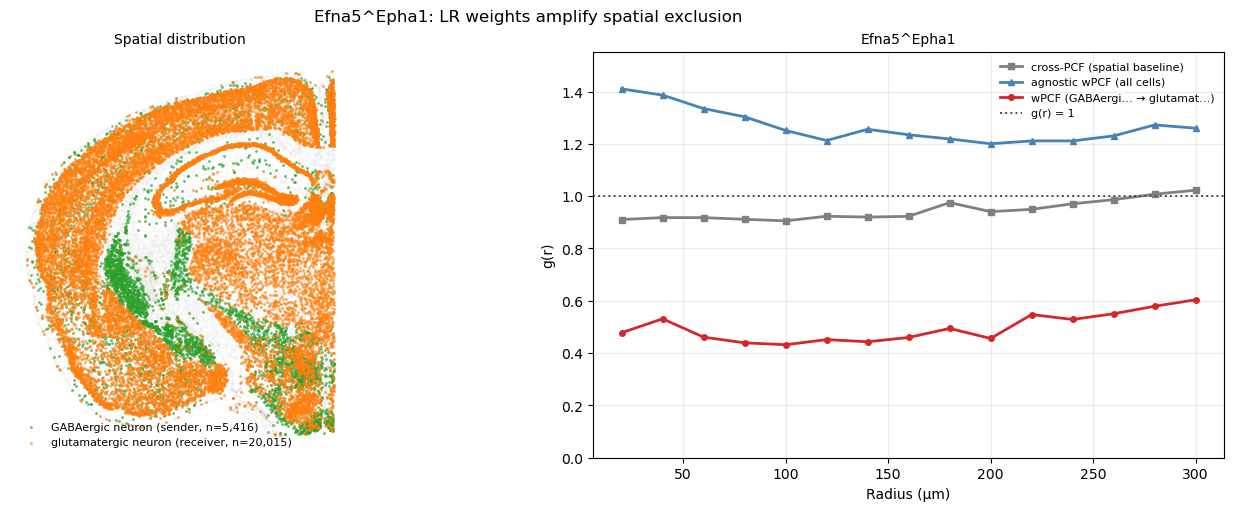

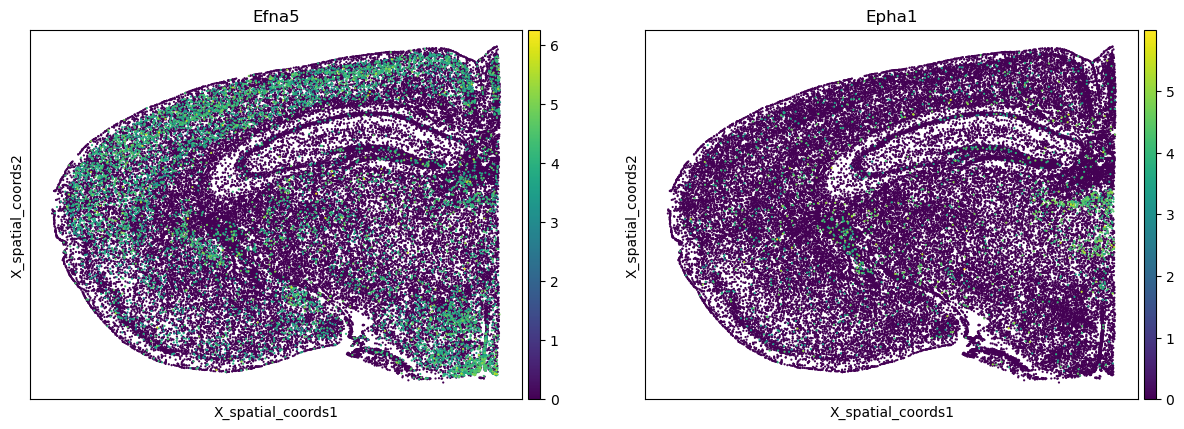

In [20]:
# Find an Efna5-involving pair present in the results
efna_pairs = [p for p in ct_pairs if "Efna5" in p]
print("Efna5 pairs available:", efna_pairs)

if efna_pairs:
    pair_efna = efna_pairs[0]
    three_way_plot(
        adata, cpcf, ag, ct,
        snd="GABAergic neuron",
        rcv="glutamatergic neuron",
        lr_pair=pair_efna,
        title=f"{pair_efna}: LR weights amplify spatial exclusion"
    )

    sc.pl.embedding(
    adata,
    basis="X_spatial_coords",
    color=["Efna5", "Epha1"],
    s=10,
    use_raw=False,
    ncols=2,
)


### 6c. Top LR pairs for a specific sender → receiver combination

Finally, we will rank all LR pairs by their peak wPCF for astrocyte -> oligodendrocyte precursor cell.

In [21]:
focus_snd, focus_rcv = "astrocyte", "oligodendrocyte precursor cell"

mat_focus = ct_wpcf[(focus_snd, focus_rcv)]  # (n_bins, n_pairs)

abs_mat = np.abs(mat_focus)

r20_idx = np.argmin(np.abs(ct_radii - 20))   # bin closest to 20 µm

top_ct_scores = pd.DataFrame({
    "pair"           : ct_pairs,
    "mean_abs_wpcf"  : abs_mat.mean(axis=0),
    "wpcf_at_r20"    : abs_mat[r20_idx],      # value at ~20 µm
    "peak_radius"    : ct_radii[abs_mat.argmax(axis=0)],
}).sort_values(
    ["wpcf_at_r20", "peak_radius"],
    ascending=[False, True]
).reset_index(drop=True)

print(f"Top 15 LR pairs for {focus_snd} → {focus_rcv} (ranked by |wPCF| at r≈{ct_radii[r20_idx]:.0f} µm):")
print(top_ct_scores.head(5).to_string(index=False))

Top 15 LR pairs for astrocyte → oligodendrocyte precursor cell (ranked by |wPCF| at r≈20 µm):
       pair  mean_abs_wpcf  wpcf_at_r20  peak_radius
 Pdyn^Oprk1       2.695438     7.377429         20.0
 Lamb3^Cd44       2.198374     5.383667         80.0
  Crh^Crhr1       1.616674     4.384574         20.0
Efna5^Epha8       1.555741     4.023735         20.0
 Vcan^Itga4       1.271896     3.829613         20.0


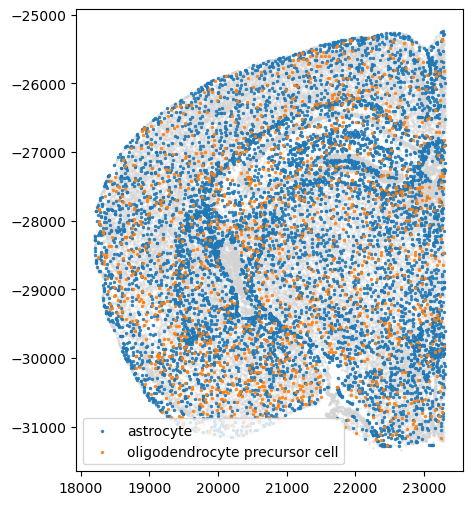

In [22]:
coords = adata.obsm["X_spatial_coords"]
cell_type = adata.obs["cell_type"]

mask_A = cell_type == focus_snd
mask_B = cell_type == focus_rcv
mask_other = ~(mask_A | mask_B)

plt.figure(figsize=(6, 6))

# 1) plot all other cells in grey (background)
plt.scatter(
    coords[mask_other, 0],
    coords[mask_other, 1],
    s=3,
    c="lightgrey",
    alpha=0.5,
    linewidths=0
)

# 2) astrocytes (highlight)
plt.scatter(
    coords[mask_A, 0],
    coords[mask_A, 1],
    s=6,
    c="tab:blue",
    label=focus_snd,
    alpha=0.9,
    linewidths=0
)

# 3) oligodendrocytes (highlight)
plt.scatter(
    coords[mask_B, 0],
    coords[mask_B, 1],
    s=6,
    c="tab:orange",
    label=focus_rcv,
    alpha=0.9,
    linewidths=0
)

plt.gca().set_aspect("equal")
plt.legend()
plt.show()

In [23]:
top_lr = top_ct_scores.head(5)["pair"].tolist()

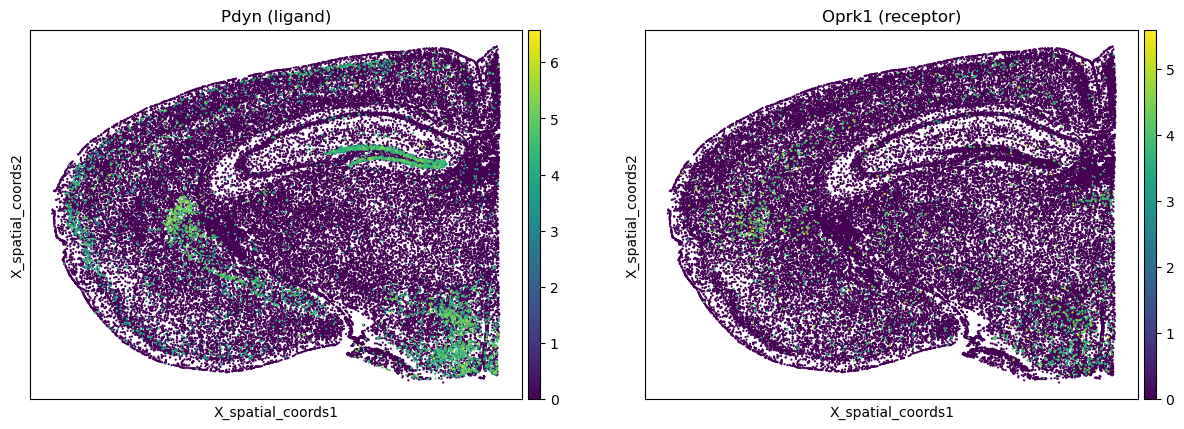

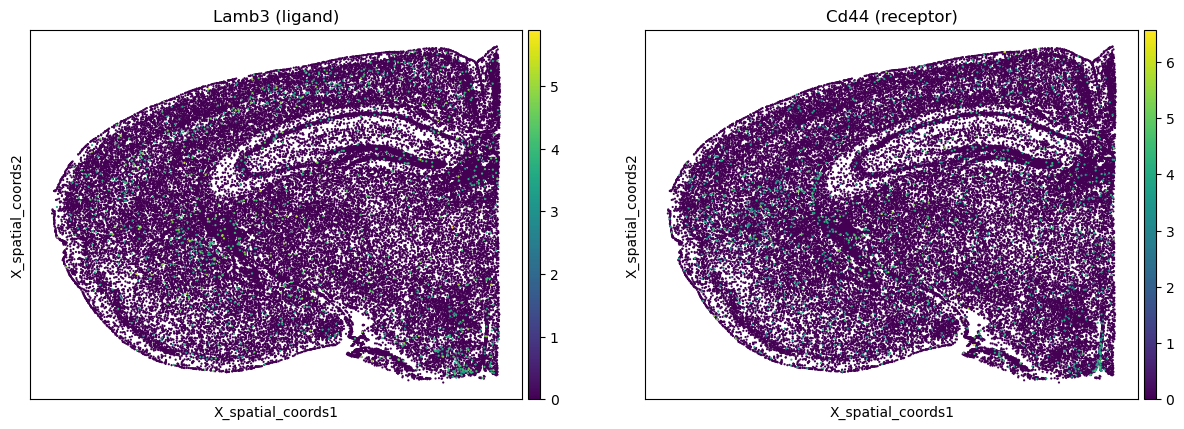

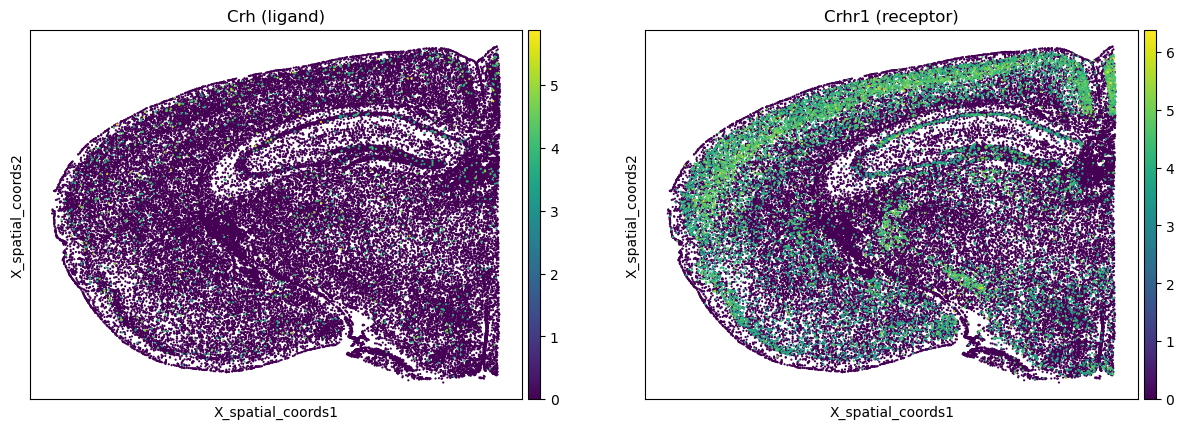

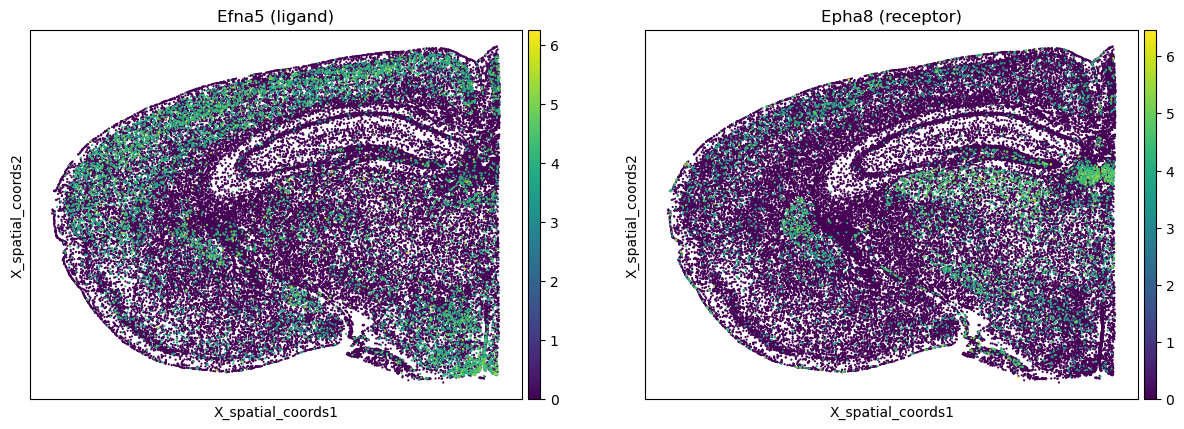

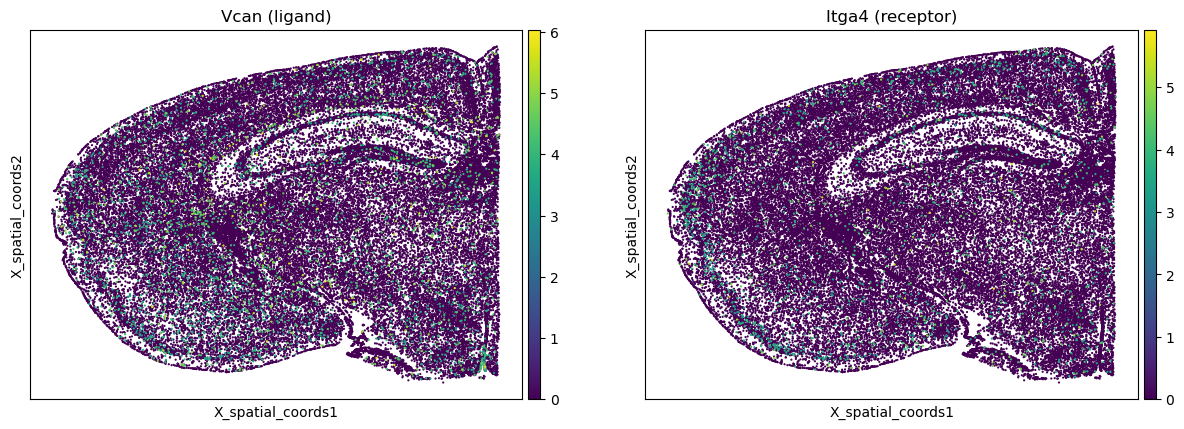

In [24]:
# Split each pair into ligand and receptor
top_lr_split = [pair.split("^") for pair in top_lr]

# Now iterate and plot
for l, r in top_lr_split:
    sc.pl.embedding(
        adata,
        basis="X_spatial_coords",  # or the appropriate basis; commonly "spatial" or "X_spatial"
        color=[l, r],
        s=10,
        ncols=2,
        title=[f"{l} (ligand)", f"{r} (receptor)"],
        use_raw=False  # Change to True if you want to use .raw data.
    )

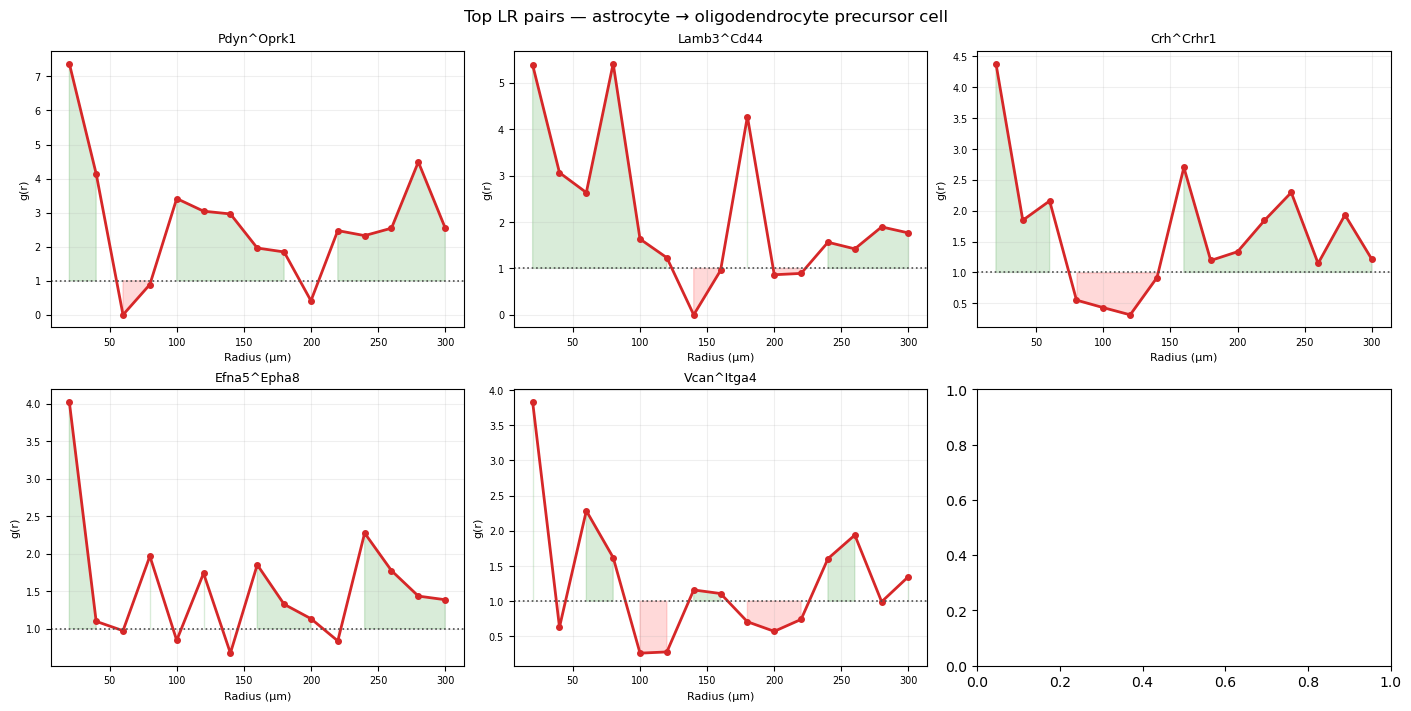

In [26]:
PLOT_TOP =5 

if (focus_snd, focus_rcv) in ct_wpcf:
    top_lr = top_ct_scores.head(PLOT_TOP)["pair"].tolist()

    fig, axes = plt.subplots(2, 3, figsize=(14, 7), layout="constrained")
    for ax, pair in zip(axes.flat, top_lr):
        idx = ct_pairs.index(pair)
        g   = mat_focus[:, idx]
        ax.plot(ct_radii, g, lw=2, marker="o", ms=4, color="tab:red")
        ax.axhline(1, linestyle=":", color="0.3", lw=1.2)
        ax.fill_between(ct_radii, 1, g, where=g > 1, alpha=0.15, color="green")
        ax.fill_between(ct_radii, g, 1, where=g < 1, alpha=0.15, color="red")
        ax.set_title(pair, fontsize=9)
        ax.set_xlabel("Radius (µm)", fontsize=8)
        ax.set_ylabel("g(r)", fontsize=8)
        ax.grid(alpha=0.2); ax.tick_params(labelsize=7)

    fig.suptitle(f"Top LR pairs — {focus_snd} → {focus_rcv}", fontsize=12)
    plt.show()

---